# Age Estimation - Google Colab Setup

Ce notebook configure l'environnement sur Google Colab pour le projet d'estimation d'âge.

## 1. Clone le repository GitHub

In [13]:
# Supprime le dossier s'il existe déjà (pour réexécution)
!rm -rf Deep-learning-project

# Clone le repository GitHub
!git clone https://github.com/Lduvignacq/Deep-learning-project.git
%cd Deep-learning-project

Cloning into 'Deep-learning-project'...
remote: Enumerating objects: 71, done.
remote: Counting objects: 100% (71/71), done.
remote: Compressing objects: 100% (45/45), done.
remote: Enumerating objects: 71, done.
remote: Counting objects: 100% (71/71), done.
remote: Compressing objects: 100% (45/45), done.
remote: Total 71 (delta 35), reused 62 (delta 26), pack-reused 0 (from 0)
Receiving objects: 100% (71/71), 1.26 MiB | 4.69 MiB/s, done.
Resolving deltas: 100% (35/35), done.
/content/Deep-learning-project/Deep-learning-project/Deep-learning-project/Deep-learning-project
remote: Total 71 (delta 35), reused 62 (delta 26), pack-reused 0 (from 0)
Receiving objects: 100% (71/71), 1.26 MiB | 4.69 MiB/s, done.
Resolving deltas: 100% (35/35), done.
/content/Deep-learning-project/Deep-learning-project/Deep-learning-project/Deep-learning-project


## 2. Installe les dépendances

**Note importante :** Les packages sont installés dans un ordre spécifique :
1. Packages de base et dépendances
2. PyTorch et TensorBoard
3. **albumentations** (au lieu de imgaug, compatible avec NumPy 2.0+)

✅ **Changement :** On utilise `albumentations` au lieu de `imgaug` car ce dernier n'est pas compatible avec NumPy 2.0 et Python 3.12.

In [14]:
# Mise à jour de pip et installation des dépendances
!pip install --upgrade pip -q

# Installation de better-exceptions en premier (requis par train.py)
!pip install -q better-exceptions

# Installation des packages de base
!pip install -q future pandas tqdm yacs pretrainedmodels

# Installation de PyTorch et TensorBoard
!pip install -q torch torchvision tensorboard

# Installation des packages d'images (avec albumentations au lieu de imgaug)
!pip install -q scikit-image imageio Pillow matplotlib Shapely scipy six numpy opencv-python

# Installation d'albumentations (alternative moderne à imgaug, compatible NumPy 2.0)
!pip install -q albumentations

print("✅ Installation terminée !")
print("✅ albumentations installé (compatible NumPy 2.0+)")

✅ Installation terminée !
✅ albumentations installé (compatible NumPy 2.0+)


✅ **Modification du code :** Le fichier `dataset.py` a été modifié pour utiliser `albumentations` au lieu de `imgaug`, ce qui résout tous les problèmes de compatibilité avec NumPy 2.0 et Python 3.12.

## 3. Télécharge le dataset APPA-REAL

In [15]:
# Monte Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Copie le dataset depuis Google Drive vers l'environnement Colab
# INSTRUCTIONS:
# 1. Uploadez d'abord appa-real-release.zip dans votre Google Drive (dans "Mon Drive")
# 2. Puis exécutez cette cellule

import os
zip_path = '/content/drive/MyDrive/appa-real-release.zip'

if os.path.exists(zip_path):
    print("📦 Copie et décompression du dataset depuis Google Drive...")
    !cp /content/drive/MyDrive/appa-real-release.zip .
    # Utilise -o pour overwrite automatiquement (évite les prompts)
    !unzip -o -q appa-real-release.zip
    # Supprime les fichiers macOS cachés
    !rm -rf __MACOSX
    print("✅ Dataset prêt !")
    !ls -la appa-real-release/
else:
    print(f"❌ Fichier non trouvé: {zip_path}")
    print("📁 Veuillez uploader appa-real-release.zip dans 'Mon Drive' sur Google Drive d'abord.")
    print("   Ou ajustez le chemin ci-dessus si le fichier est dans un autre dossier.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📦 Copie et décompression du dataset depuis Google Drive...
✅ Dataset prêt !
total 7168
drwx------ 5 root root    4096 Feb 24 13:12 .
drwxr-xr-x 5 root root    4096 Feb 24 14:57 ..
-rw-rw---- 1 root root    5938 May  5  2017 .badfiles.un~
-rw-rw---- 1 root root    4452 May  5  2017 .clean_asdf.sh.un~
-rw-rw---- 1 root root   98228 May  5  2017 gt_avg_test.csv
-rw-rw---- 1 root root  200274 May  5  2017 gt_avg_train.csv
-rw-rw---- 1 root root   72952 May  5  2017 gt_avg_valid.csv
-rw-rw---- 1 root root 1951895 May  5  2017 gt_test.csv
-rw------- 1 root root 2917229 May  5  2017 gt_train.csv
-rw------- 1 root root 1116835 May  5  2017 gt_valid.csv
-rw-rw---- 1 root root   19103 May  5  2017 .parse_labels.m.un~
-rw-rw---- 1 root root    1588 May  5  2017 README.txt
-rw-rw---- 1 root root   66878 May  5  2017 .README.txt.un~
drwxr-x--- 2 root root  237568 Feb 24 1

## 4. Vérifie que le dataset fonctionne

In [16]:
# Vérification du répertoire courant et des fichiers
!pwd
!ls -la

# Test du dataset
!python dataset.py --data_dir appa-real-release

/content/Deep-learning-project/Deep-learning-project/Deep-learning-project/Deep-learning-project
total 873548
drwxr-xr-x 5 root root      4096 Feb 24 14:57 .
drwxr-xr-x 9 root root      4096 Feb 24 14:56 ..
drwx------ 5 root root      4096 Feb 24 13:12 appa-real-release
-rw------- 1 root root 894405507 Feb 24 14:57 appa-real-release.zip
-rw-r--r-- 1 root root     17839 Feb 24 14:56 colab_setup.ipynb
-rw-r--r-- 1 root root      3177 Feb 24 14:56 dataset.py
-rw-r--r-- 1 root root       537 Feb 24 14:56 defaults.py
-rw-r--r-- 1 root root      6296 Feb 24 14:56 demo.py
drwxr-xr-x 8 root root      4096 Feb 24 14:56 .git
-rw-r--r-- 1 root root       376 Feb 24 14:56 .gitignore
-rw-r--r-- 1 root root      1307 Feb 24 14:56 ignore_list.csv
drwxr-xr-x 2 root root      4096 Feb 24 14:56 misc
-rw-r--r-- 1 root root       500 Feb 24 14:56 model.py
-rw-r--r-- 1 root root      4487 Feb 24 14:56 README.md
-rw-r--r-- 1 root root       212 Feb 24 14:56 requirements.txt
-rw-r--r-- 1 root root       444 

## 5. Vérifie le GPU disponible

In [17]:
import torch
print(f"CUDA disponible: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Mémoire GPU: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

CUDA disponible: True
GPU: Tesla T4
Mémoire GPU: 15.64 GB


## 6. Entraîne le modèle

⚠️ **Optimisations pour accélérer l'entraînement :**
- `TRAIN.BATCH_SIZE 64` : Batch size augmenté (32 → 64) pour plus de vitesse
- `TRAIN.WORKERS 4` : Réduit les workers (8 → 4) pour éviter la surcharge
- `TRAIN.EPOCHS 30` : Réduisez si vous voulez un test rapide (par défaut: 80)

💡 **Astuce :** Si vous obtenez "Out of Memory", remettez `TRAIN.BATCH_SIZE 32`

In [25]:
# Essayez batch_size 64 ou 96 si le GPU le permet (plus rapide)
# Si erreur OOM, revenez à 32
!python train.py --data_dir appa-real-release --tensorboard tf_log TRAIN.BATCH_SIZE 96 TRAIN.WORKERS 2 TRAIN.EPOCHS 30

2026-02-24 15:10:17.291604: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771945817.312296   21726 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771945817.319132   21726 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1771945817.336356   21726 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771945817.336382   21726 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771945817.336386   21726 computation_placer.cc:177] computation placer alr

## 7. Visualise TensorBoard

📊 **TensorBoard** affiche les métriques d'entraînement en temps réel :
- Loss (entraînement & validation)
- Accuracy
- Learning rate
- MAE (Mean Absolute Error)

⚠️ **Note :** Exécutez cette cellule pendant ou après l'entraînement

In [20]:
%load_ext tensorboard
%tensorboard --logdir tf_log

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


<IPython.core.display.Javascript object>

## 8. Visualisations personnalisées

Créez des graphiques détaillés des résultats d'entraînement

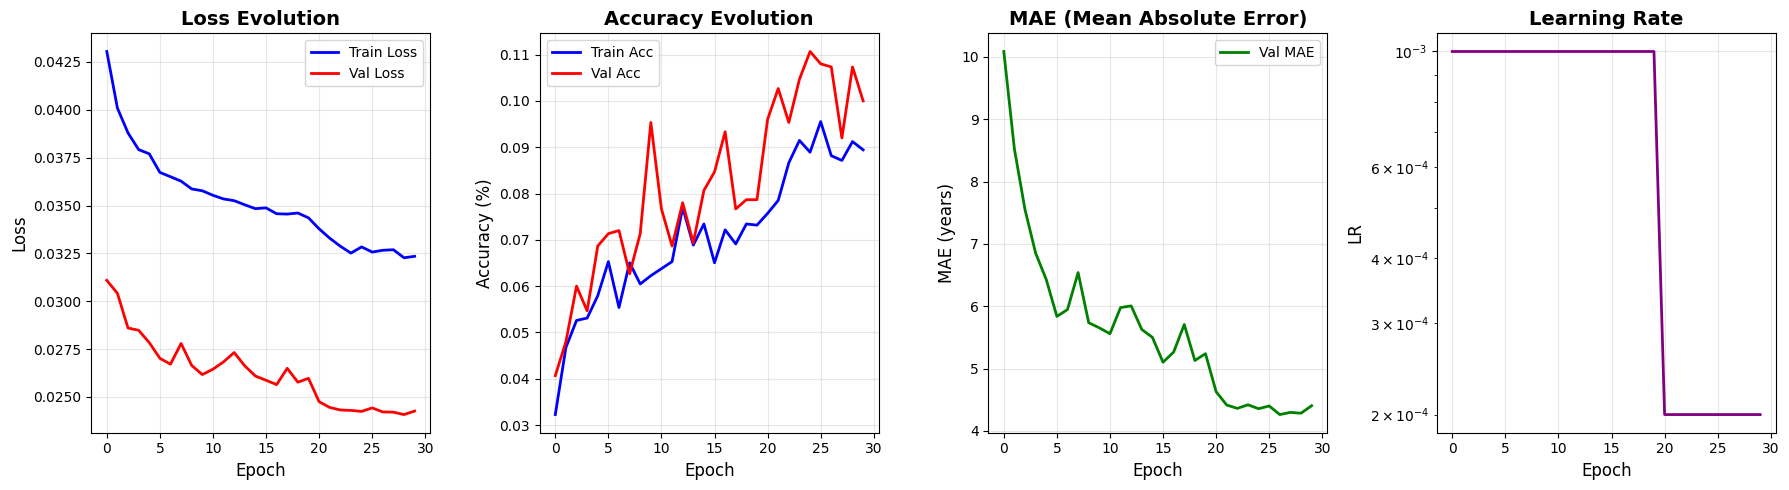

� Statistiques finales :
   Best Train Loss: 0.0323 (epoch 28)
   Best Val Loss: 0.0241 (epoch 28)
   Best Train Acc: 0.10% (epoch 25)
   Best Val Acc: 0.11% (epoch 24)
   Best MAE: 4.262 years (epoch 26)


In [26]:
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

# Lecture des métriques sauvegardées par train.py
metrics_file = Path('checkpoint/training_metrics.csv')

if metrics_file.exists():
    df = pd.read_csv(metrics_file)
    
    plt.figure(figsize=(18, 5))
    
    # Loss
    plt.subplot(1, 4, 1)
    plt.plot(df['epoch'], df['train_loss'], 'b-', label='Train Loss', linewidth=2)
    plt.plot(df['epoch'], df['val_loss'], 'r-', label='Val Loss', linewidth=2)
    plt.title('Loss Evolution', fontsize=14, fontweight='bold')
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)
    
    # Accuracy
    plt.subplot(1, 4, 2)
    plt.plot(df['epoch'], df['train_acc'], 'b-', label='Train Acc', linewidth=2)
    plt.plot(df['epoch'], df['val_acc'], 'r-', label='Val Acc', linewidth=2)
    plt.title('Accuracy Evolution', fontsize=14, fontweight='bold')
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Accuracy (%)', fontsize=12)
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)
    
    # MAE
    plt.subplot(1, 4, 3)
    plt.plot(df['epoch'], df['val_mae'], 'g-', label='Val MAE', linewidth=2)
    plt.title('MAE (Mean Absolute Error)', fontsize=14, fontweight='bold')
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('MAE (years)', fontsize=12)
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)
    
    # Learning Rate
    plt.subplot(1, 4, 4)
    plt.plot(df['epoch'], df['learning_rate'], 'purple', linewidth=2)
    plt.title('Learning Rate', fontsize=14, fontweight='bold')
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('LR', fontsize=12)
    plt.yscale('log')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("? Statistiques finales :")
    print(f"   Best Train Loss: {df['train_loss'].min():.4f} (epoch {df.loc[df['train_loss'].idxmin(), 'epoch']:.0f})")
    print(f"   Best Val Loss: {df['val_loss'].min():.4f} (epoch {df.loc[df['val_loss'].idxmin(), 'epoch']:.0f})")
    print(f"   Best Train Acc: {df['train_acc'].max():.2f}% (epoch {df.loc[df['train_acc'].idxmax(), 'epoch']:.0f})")
    print(f"   Best Val Acc: {df['val_acc'].max():.2f}% (epoch {df.loc[df['val_acc'].idxmax(), 'epoch']:.0f})")
    print(f"   Best MAE: {df['val_mae'].min():.3f} years (epoch {df.loc[df['val_mae'].idxmin(), 'epoch']:.0f})")
else:
    print("❌ Fichier de métriques non trouvé. Entraînez d'abord le modèle (cellule 6)!")
    print(f"   Attendu : {metrics_file}")

## 9. Teste le modèle sur des exemples

Visualise les prédictions d'âge sur des images du dataset de test

✅ Modèle chargé depuis epoch026_0.02421_4.2625.pth
   Epoch: 27


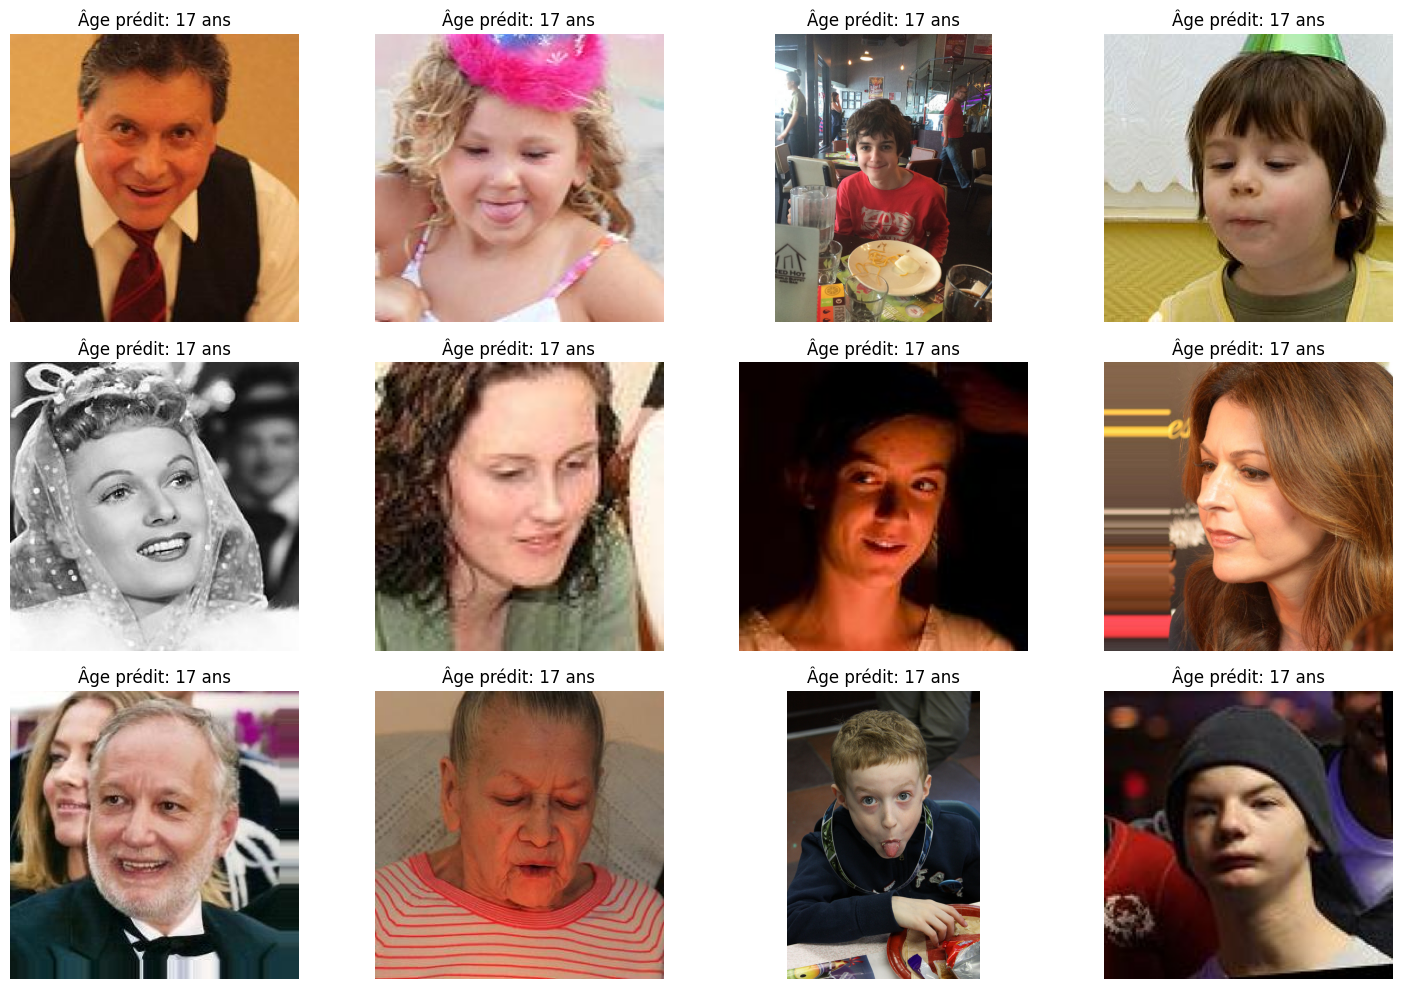

In [27]:
import torch
import cv2
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from model import get_model
from defaults import _C as cfg
import random
import glob

# Charge le meilleur modèle
device = "cuda" if torch.cuda.is_available() else "cpu"
model = get_model(model_name=cfg.MODEL.ARCH)
model = model.to(device)

# Trouve automatiquement le meilleur checkpoint (celui avec le plus petit MAE)
checkpoint_dir = Path('checkpoint')
if checkpoint_dir.exists():
    checkpoints = list(checkpoint_dir.glob('*.pth'))
    if checkpoints:
        # Trie par MAE (dernier nombre dans le nom du fichier)
        best_checkpoint = min(checkpoints, key=lambda p: float(p.stem.split('_')[-1]))
        checkpoint_path = best_checkpoint
        
        checkpoint = torch.load(checkpoint_path, map_location=device)
        model.load_state_dict(checkpoint['state_dict'])
        model.eval()
        print(f"✅ Modèle chargé depuis {checkpoint_path.name}")
        print(f"   Epoch: {checkpoint.get('epoch', 'N/A')}")
    else:
        print("❌ Aucun checkpoint (.pth) trouvé dans le dossier checkpoint/")
        print("   Entraînez d'abord le modèle (cellule 6)!")
        checkpoint_path = None
else:
    print("❌ Dossier checkpoint/ non trouvé. Entraînez d'abord le modèle (cellule 6)!")
    checkpoint_path = None

# Fonction de prédiction
def predict_age(img_path, model, device):
    img = cv2.imread(str(img_path))
    img = cv2.resize(img, (224, 224))
    img = img.astype(np.float32) / 255.0
    img = img.transpose(2, 0, 1)  # HWC to CHW
    img = torch.from_numpy(img).unsqueeze(0).to(device)
    
    with torch.no_grad():
        outputs = model(img)
        predicted_age = int(outputs.argmax(1).item())
    
    return predicted_age

# Visualise quelques prédictions (seulement si le modèle est chargé)
if checkpoint_path:
    test_dir = Path('appa-real-release/test')
    if test_dir.exists():
        test_images = list(test_dir.glob('*.jpg'))[:12]  # 12 premières images
        
        plt.figure(figsize=(15, 10))
        for i, img_path in enumerate(test_images):
            predicted_age = predict_age(img_path, model, device)
            
            img = cv2.imread(str(img_path))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            
            plt.subplot(3, 4, i+1)
            plt.imshow(img)
            plt.title(f'Âge prédit: {predicted_age} ans', fontsize=12)
            plt.axis('off')
        
        plt.tight_layout()
        plt.show()
    else:
        print("❌ Dossier test non trouvé!")

## 10. Analyse de performance par tranche d'âge

Évalue la précision du modèle selon différentes tranches d'âge

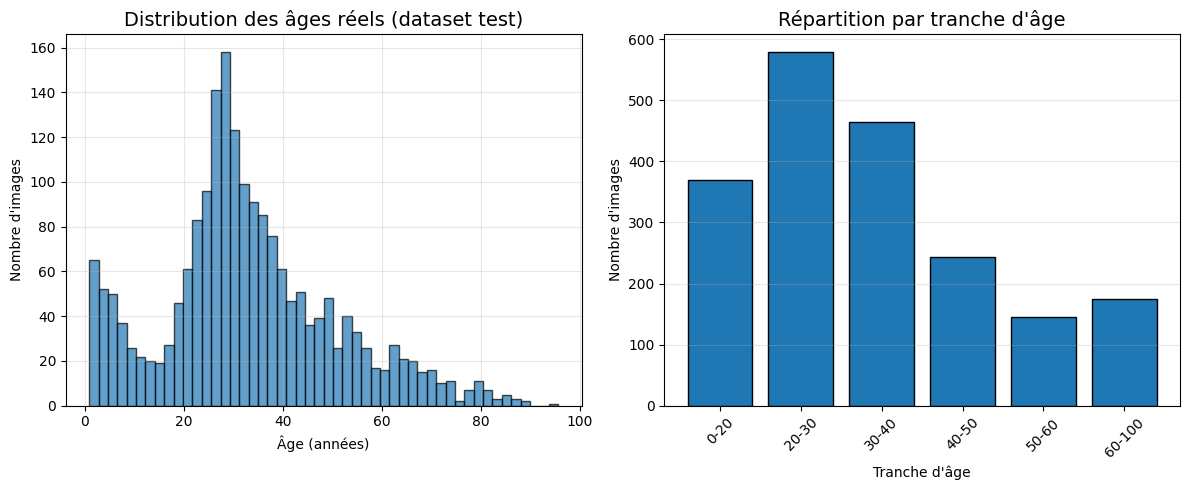

📊 Dataset test : 1978 images
📈 Âge moyen : 33.1 ans
📉 Âge min : 1 ans
📈 Âge max : 96 ans


In [23]:
import pandas as pd
import seaborn as sns

# Lecture des résultats (vous devez d'abord exécuter test.py pour générer ces résultats)
# !python test.py --data_dir appa-real-release --resume checkpoint/epoch080_0.00000_3.00000.pth

# Exemple de visualisation de distribution d'âges
csv_path = Path('appa-real-release/gt_avg_test.csv')
if csv_path.exists():
    df = pd.read_csv(csv_path)
    
    # Distribution des âges réels
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.hist(df['apparent_age_avg'], bins=50, edgecolor='black', alpha=0.7)
    plt.title('Distribution des âges réels (dataset test)', fontsize=14)
    plt.xlabel('Âge (années)')
    plt.ylabel('Nombre d\'images')
    plt.grid(True, alpha=0.3)
    
    plt.subplot(1, 2, 2)
    # Statistiques par tranche d'âge
    age_ranges = [(0, 20), (20, 30), (30, 40), (40, 50), (50, 60), (60, 100)]
    counts = []
    for min_age, max_age in age_ranges:
        count = len(df[(df['apparent_age_avg'] >= min_age) & (df['apparent_age_avg'] < max_age)])
        counts.append(count)
    
    plt.bar([f'{min_age}-{max_age}' for min_age, max_age in age_ranges], counts, edgecolor='black')
    plt.title('Répartition par tranche d\'âge', fontsize=14)
    plt.xlabel('Tranche d\'âge')
    plt.ylabel('Nombre d\'images')
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    print(f"📊 Dataset test : {len(df)} images")
    print(f"📈 Âge moyen : {df['apparent_age_avg'].mean():.1f} ans")
    print(f"📉 Âge min : {df['apparent_age_avg'].min():.0f} ans")
    print(f"📈 Âge max : {df['apparent_age_avg'].max():.0f} ans")
else:
    print("❌ Fichier CSV du dataset test non trouvé")